### Working w/ Larger Example (Multiclass Classification)

When you have more than 2 classes as a target, it's known as **Multiclass Classification**.
- Which is, if you have more than 2 either that's 3 or even 100 of target, it's called multiclass classification.

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

#### Understanding Data

In [3]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [4]:
# Data shape
(train_data[69].shape, train_labels[69].shape)

((28, 28), ())

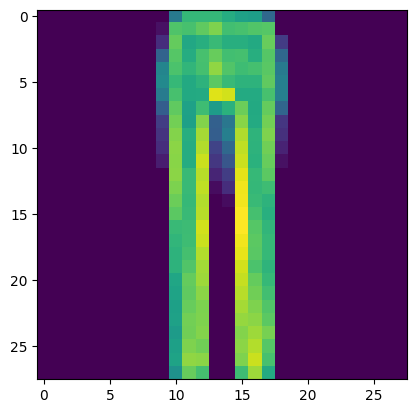

In [5]:
# Visualize the data
import matplotlib.pyplot as plt
plt.imshow(train_data[69])

In [6]:
# Check sample label
train_labels[69]

np.uint8(1)

In [7]:
# Create Labels
class_name = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
len(class_name)

10

Text(0.5, 1.0, 'Shirt')

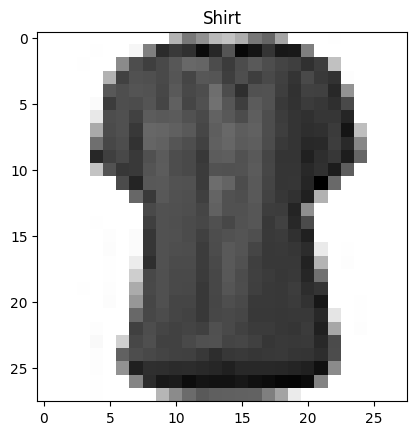

In [8]:
# Plot an example image and its label
index_data = 55
plt.imshow(train_data[index_data], cmap=plt.cm.binary)
plt.title(class_name[train_labels[index_data]])

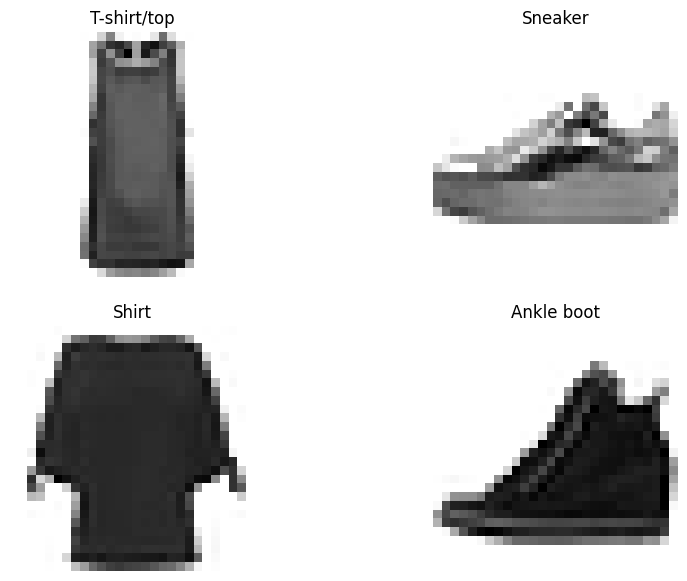

In [9]:
import random as rand
plt.figure(figsize=(10, 7))
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    rand_index = rand.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_name[train_labels[rand_index]])
    plt.axis(False)

#### Building Multiclass Classification Model
For the model, we use a similiar architecture the latest binary classification model 6 on Course 6, however,
we're going to have to tweak the model, so it can match with our problem. Things we're going to change:
- Input shape: 28x28 (the shape of one train_data)
- Output shape: 10 (one per classes of clothing)
- Loss function: tf.keras.losses.CategoricalCrossentropy()
    - If your labels are one hot encoded, use CategoricalCrossentropy()
    - And if your labels are integer form, use SparseCategoricalCrossentropy()
- Output layer = softmax

In [10]:
# The data need to be flattened first (from 28*28 to None, 784)
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])
flatten_model.output_shape

c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [11]:
# Set random seed
tf.random.set_seed(42)

# Create model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile Model
model_1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit Model
non_norm_hist = model_1.fit(train_data, tf.one_hot(train_labels, depth=10), epochs=10, validation_data=(test_data, tf.one_hot(test_labels, depth=10)))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1248 - loss: 2.6193 - val_accuracy: 0.3327 - val_loss: 1.7204
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3981 - loss: 1.5589 - val_accuracy: 0.4730 - val_loss: 1.2885
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4746 - loss: 1.2863 - val_accuracy: 0.4711 - val_loss: 1.2564
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4971 - loss: 1.2161 - val_accuracy: 0.5218 - val_loss: 1.1780
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5234 - loss: 1.1485 - val_accuracy: 0.5310 - val_loss: 1.0955
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5570 - loss: 1.0631 - val_accuracy: 0.6295 - val_loss: 0.9821
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6030 - loss: 0.9861 - val_accuracy: 0.6322 - val_loss: 0.9603
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6150 - loss: 0.9531 - 

In [12]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [13]:
# Check the min and max val of train data
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

Neural network prefer data to be scaled (or normalized), this means they like to have numbers in the tensors they try to find patterns between 0 & 1

In [14]:
# We can get out training data between 0 & 1 by dividing by the maximum
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

In [15]:
# Set random seed
tf.random.set_seed(42)

# Create model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile model
model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit model
norm_hist = model_2.fit(train_data_norm, 
                        train_labels, 
                        epochs=10, 
                        validation_data=(test_data_norm, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4474 - loss: 1.4843 - val_accuracy: 0.7489 - val_loss: 0.7182
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7631 - loss: 0.6811 - val_accuracy: 0.7893 - val_loss: 0.6153
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7982 - loss: 0.5878 - val_accuracy: 0.8013 - val_loss: 0.5833
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8095 - loss: 0.5556 - val_accuracy: 0.8085 - val_loss: 0.5691
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8165 - loss: 0.5379 - val_accuracy: 0.8114 - val_loss: 0.5605
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8213 - loss: 0.5257 - val_accuracy: 0.8140 - val_loss: 0.5539
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8237 - loss: 0.5161 - val_accuracy: 0.8148 - val_loss: 0.5500
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8259 - loss: 0.5087 - 

📝Note: Nerual Network tend to prefer data in numerical form as well as scaled/normalization (0 & 1 numbers)

<Axes: title={'center': 'Non Normalized Data'}>

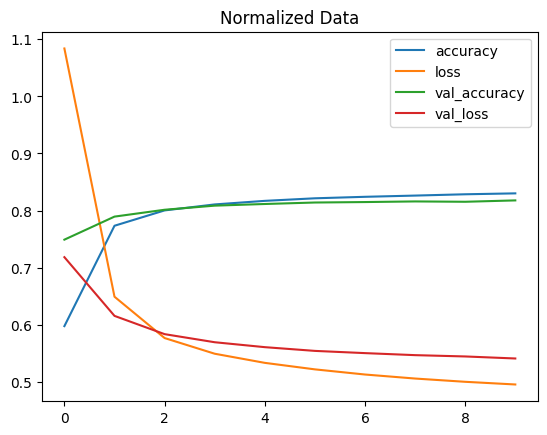

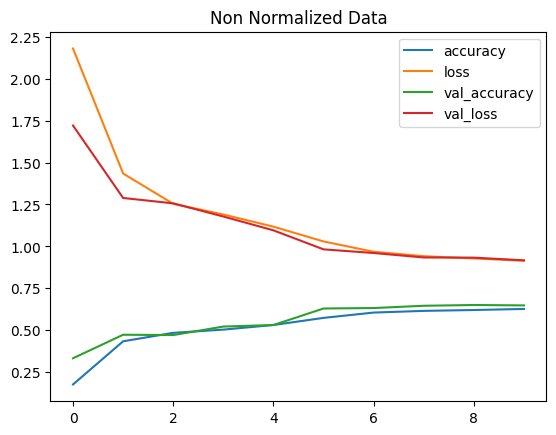

In [16]:
import pandas as pd
pd.DataFrame(norm_hist.history).plot(title="Normalized Data")
pd.DataFrame(non_norm_hist.history).plot(title="Non Normalized Data")

📝Note: If you want to comparing models, make sure comparing same model criteria (e.g same model architecture but different data, or same data but different model architecture).

#### Finding the Ideal Learning Rate


In [17]:
# Random set seed
tf.random.set_seed(42)

# Create model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax"),
])

# Model compile
model_3.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Create learning rate scheduler
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/2))

# Fit the model
find_lr_hist = model_3.fit(train_data_norm, train_labels, epochs=40,
            validation_data=(test_data_norm, test_labels),
            callbacks=[lr_scheduler])


c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4501 - loss: 1.5255 - val_accuracy: 0.7325 - val_loss: 0.8530 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7286 - loss: 0.7880 - val_accuracy: 0.7801 - val_loss: 0.6347 - learning_rate: 0.0032
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7574 - loss: 0.6727 - val_accuracy: 0.7870 - val_loss: 0.5996 - learning_rate: 0.0100
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7246 - loss: 0.7858 - val_accuracy: 0.7671 - val_loss: 0.6882 - learning_rate: 0.0316
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3459 - loss: 1.6076 - val_accuracy: 0.4196 - val_loss: 1.3551 - learning_rate: 0.1000
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1195 - loss: 2.3343 - val_accuracy: 0.1000 - val_loss: 2.3129 - learning_rate: 0.3162
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1001 - l

Text(0.5, 1.0, 'Finding ideal learning rate')

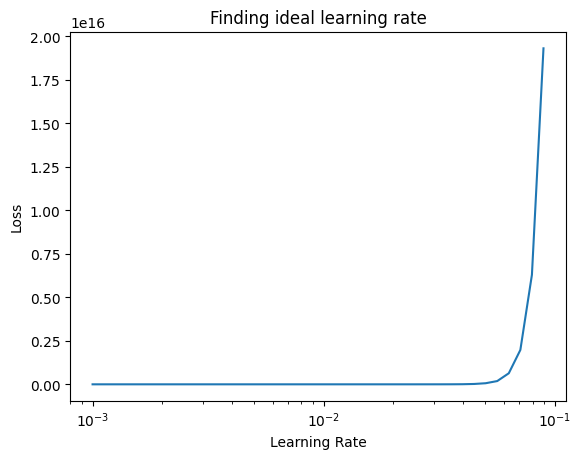

In [18]:
import numpy as np
import matplotlib.pyplot as plt

lrs = 1e-3 * (10**(tf.range(40)/20))
plt.semilogx(lrs, find_lr_hist.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Finding ideal learning rate")

In [19]:
# Random set seed
tf.random.set_seed(42)

# Create model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Model complie
model_4.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# Fit model
hist_4 = model_4.fit(train_data_norm, train_labels, 
            epochs=20, validation_data=(test_data_norm, test_labels))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4492 - loss: 1.5157 - val_accuracy: 0.7304 - val_loss: 0.8018
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7329 - loss: 0.7690 - val_accuracy: 0.7546 - val_loss: 0.7127
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7574 - loss: 0.6906 - val_accuracy: 0.7657 - val_loss: 0.6674
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7740 - loss: 0.6315 - val_accuracy: 0.7812 - val_loss: 0.6144
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7862 - loss: 0.5902 - val_accuracy: 0.7885 - val_loss: 0.5930
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7951 - loss: 0.5692 - val_accuracy: 0.7938 - val_loss: 0.5794
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8003 - loss: 0.5554 - val_accuracy: 0.7961 - val_loss: 0.5724
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8031 - loss: 0.5454 - 

#### Evaluating Our Multiclass Classification Model

##### Confusion Matrix

In [20]:
# Create a confusion matrix 
import itertools
from sklearn.metrics import confusion_matrix
figsize=(10, 10)

def plot_confusion_matrix(y_true, y_pred, classes=None, figsize=(10,10), text_size=15):
    cm = confusion_matrix(y_true, y_pred)
    # Normalize confusion matrix
    cm_norm = cm.astype("float")/cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]

    # make a plot
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    # Create classes
    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])

    ax.plot(linewidth=0.5, edgecolor="black")
    # Label the axes
    ax.set(
        title="Confusion Matrix of Model 6",
        xlabel="Prediction Label",
        ylabel="Truth Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels
    )

    # Set x-axis label
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()

    # Adjust label size
    ax.yaxis.label.set_size(text_size)
    ax.xaxis.label.set_size(text_size)
    ax.title.set_size(text_size)
    # Set threshold for different color
    threshold = (cm.max() + cm.min()) / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=15)

In [21]:
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [22]:
# Make some predcition with our model
y_probs = model_4.predict(test_data_norm)

# First 5 pred data
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[4.2542614e-10, 1.1109546e-11, 2.2246305e-09, 1.9696070e-06,
        3.3614653e-10, 1.3448393e-01, 5.5575079e-11, 1.5785222e-01,
        1.2382829e-04, 7.0753807e-01],
       [6.6165871e-06, 2.0362125e-11, 9.5779073e-01, 5.7257454e-05,
        1.9336246e-02, 4.8443484e-20, 1.7177768e-02, 5.4912204e-16,
        5.6314445e-03, 3.4334587e-25],
       [1.5364969e-05, 9.9956077e-01, 4.0134360e-08, 3.4329080e-04,
        7.0186361e-05, 2.7177812e-16, 1.0341567e-05, 6.8901409e-22,
        1.1663328e-09, 7.3688293e-18],
       [8.7169369e-08, 9.9952710e-01, 1.9611690e-10, 4.7050114e-04,
        2.2431757e-06, 1.2008397e-16, 1.7187595e-08, 1.1165646e-22,
        2.7270585e-11, 9.0561925e-16],
       [2.3743266e-01, 8.8863011e-04, 1.4947696e-01, 3.0407613e-02,
        2.6671870e-02, 2.4351646e-08, 5.4835200e-01, 1.5876230e-08,
        6.7702937e-03, 1.4800002e-11]], dtype=float32)

In [23]:
y_probs[0], tf.argmax(y_probs[0]), class_name[tf.argmax(y_probs[0])]

(array([4.2542614e-10, 1.1109546e-11, 2.2246305e-09, 1.9696070e-06,
        3.3614653e-10, 1.3448393e-01, 5.5575079e-11, 1.5785222e-01,
        1.2382829e-04, 7.0753807e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=9>,
 'Ankle boot')

In [24]:
# Convert all predicitons into integers
y_preds = y_probs.argmax(axis=1)

# First 10 predictions
y_preds[:10] 

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [25]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

In [26]:
model_4.evaluate(test_data_norm, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8168 - loss: 0.5289


[0.5411108732223511, 0.8112000226974487]

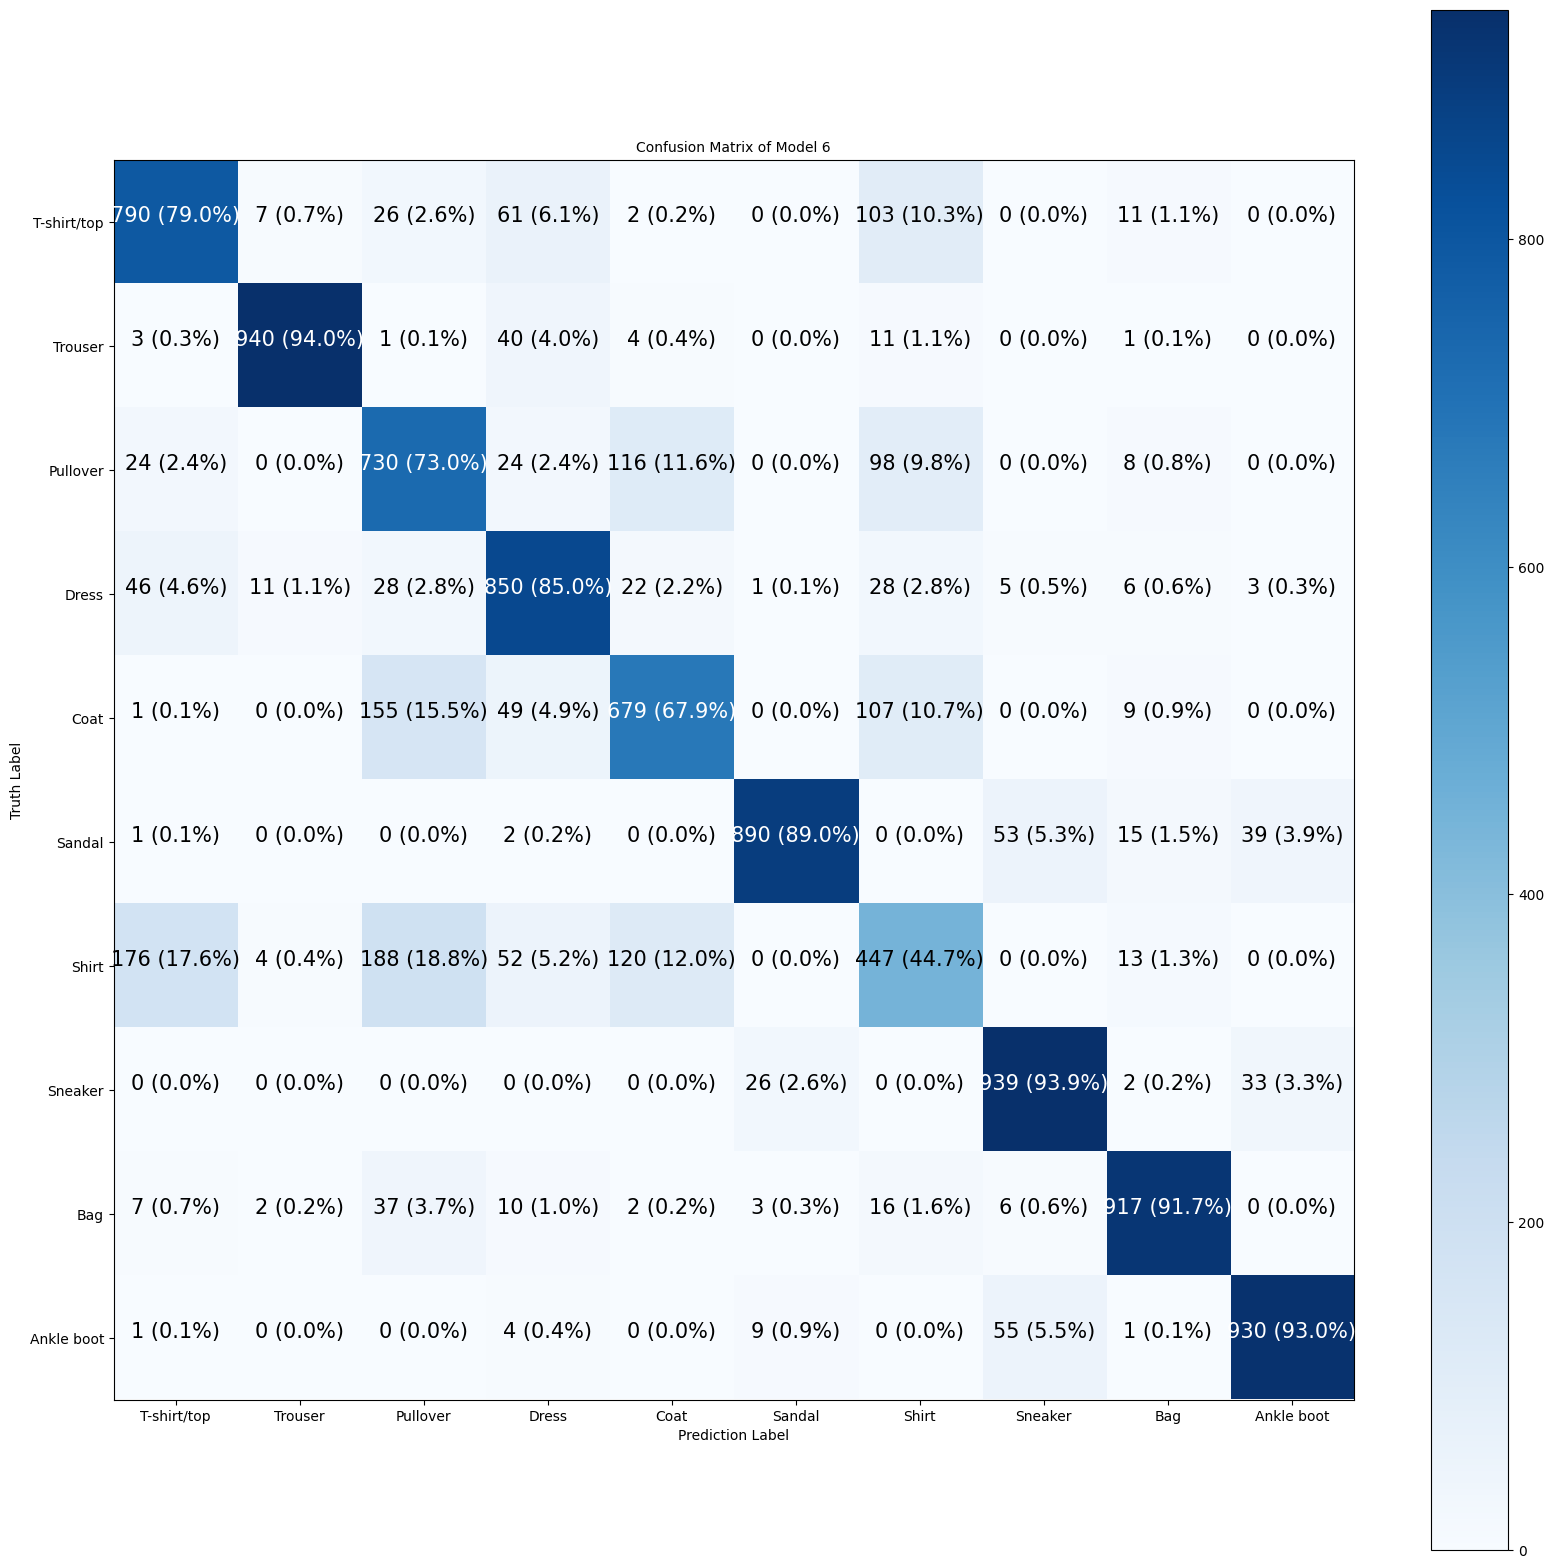

In [27]:
# Plot confusion matrix for the first 10 predictions data
plot_confusion_matrix(y_true=test_labels, y_pred=tf.round(y_preds), classes=class_name,
                      figsize=(20,20), text_size=10)

🔑**NOTE**: When working with images and other form of visual data, it's a good idea to visualize to understanding the data and the input/output of your models.


Now lets create a function for:
- Plot a random image
- Make a prediction for the random image
- Label the plot with predict & truth label

In [28]:
import random
def plot_rand_images(model, images, true_label, classes):
    """
    Pick a random images, plots it and labels it with prediction and truth label.
    """
    
    # Set up random integer
    i = random.randint(0, len(images))
    
    # Create prediction and target
    target_image = images[i]
    pred_prob = model.predict(target_image.reshape(1, 28, 28))
    pred_label = classes[pred_prob.argmax()]
    true_label = classes[true_label[i]]
    
    # Plot the image
    plt.imshow(target_image, cmap=plt.cm.binary)
    
    # Change the color for condition
    if pred_label == true_label:
        color="green"
    else:
        color="red"
        
    # Xlabel information
    plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                     100*tf.reduce_max(pred_prob),
                                                     true_label),
               color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


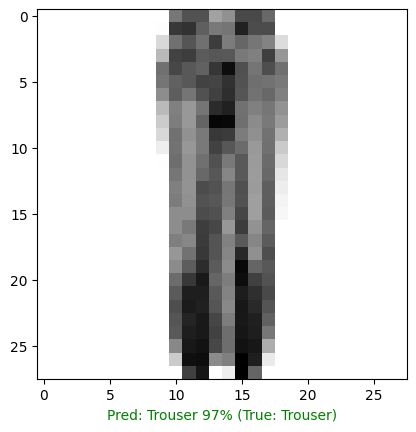

In [29]:
plot_rand_images(model=model_4, 
                 images=test_data_norm, 
                 true_label=test_labels, 
                 classes=class_name)

What Pattern is Our Model Learning ?

In [33]:
model_4.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_9, built=True>,
 <Dense name=dense_10, built=True>,
 <Dense name=dense_11, built=True>]

In [48]:
weight, biases = model_4.layers[1].get_weights()
weight, weight.shape

(array([[ 0.11110236,  0.62672704, -0.9565815 , -0.2099848 ],
        [-0.17395045,  0.939211  , -0.2764582 , -0.40047908],
        [ 1.1378351 ,  0.6740882 , -0.89853257, -0.83280313],
        ...,
        [-0.5997137 ,  0.46629423,  0.3508571 ,  0.9152366 ],
        [-0.03388476,  0.61768466, -0.32629642,  0.26268512],
        [ 0.03618152,  0.95310974, -0.2053858 , -0.36386523]],
       shape=(784, 4), dtype=float32),
 (784, 4))

In [51]:
biases, biases.shape

(array([0.9135871, 1.531131 , 1.0604749, 1.422386 ], dtype=float32), (4,))

In [53]:
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

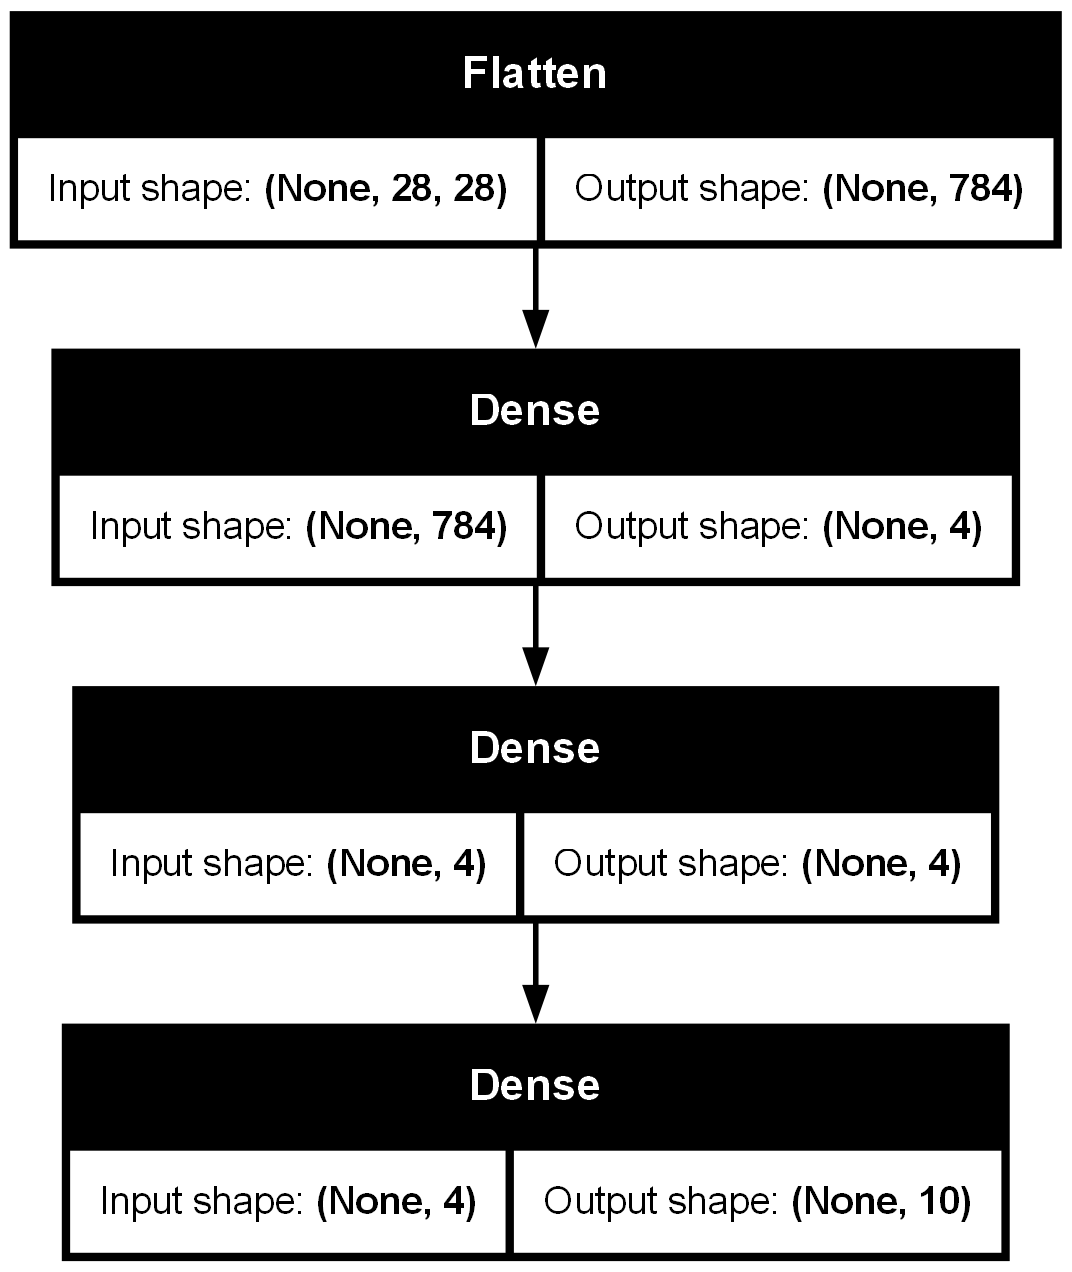

In [59]:
from tensorflow.keras.utils import plot_model
plot_model(model_4, show_shapes=True)